# 📱 Mobile Price Range Prediction

## Level 2 - Task 6: Correlation Analysis

### Objective

The objective of this task is to analyze the correlation between mobile phone specifications and price range. The analysis identifies features that have stronger relationships with the target variable and helps determine which specifications may be useful for machine learning.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [19]:
df = pd.read_csv("MobilePriceRange.csv")

df.head()

,BatteryPower,InternalMemory,ClockSpeed,NoOfCores,RAM,TalkTime,DualSim,3G,4G,WiFi,...,MobileDepth,MobileWeight,TouchScreen,ScreenHeight,ScreenWidth,FrontCameraPx,RearCameraPX,PxHeight,PxWeight,PriceRange
0,842,7,2.2,2,2549,19,0,0,0,1,...,0.6,188,0,9,7,1,2,20,756,Medium
1,1021,53,0.5,3,2631,7,1,1,1,0,...,0.7,136,1,17,3,0,6,905,1988,High
2,563,41,0.5,5,2603,9,1,1,1,0,...,0.9,145,1,11,2,2,6,1263,1716,High
3,615,10,2.5,6,2769,11,0,1,0,0,...,0.8,131,0,16,8,0,9,1216,1786,High
4,1821,44,1.2,2,1411,15,0,1,1,0,...,0.6,141,1,8,2,13,14,1208,1212,Medium


In [20]:
print("Shape:", df.shape)
print("Target classes:")
print(df["PriceRange"].value_counts())

Shape: (2000, 21)
Target classes:
PriceRange
Medium      500
High        500
VeryHigh    500
Low         500
Name: count, dtype: int64


In [21]:
price_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "VeryHigh": 3
}

df["PriceRange_Code"] = df["PriceRange"].map(price_mapping)

print(df[["PriceRange", "PriceRange_Code"]].head())

  PriceRange  PriceRange_Code
0     Medium                1
1       High                2
2       High                2
3       High                2
4     Medium                1


In [22]:
print("Missing encoded values:", df["PriceRange_Code"].isnull().sum())

Missing encoded values: 0


In [23]:
correlation = df.select_dtypes(include="number").corr()

correlation.round(2)

,BatteryPower,InternalMemory,ClockSpeed,NoOfCores,RAM,TalkTime,DualSim,3G,4G,WiFi,...,MobileDepth,MobileWeight,TouchScreen,ScreenHeight,ScreenWidth,FrontCameraPx,RearCameraPX,PxHeight,PxWeight,PriceRange_Code
BatteryPower,1.00,-0.00,0.01,-0.03,-0.00,0.05,-0.04,0.01,0.02,-0.01,...,0.03,0.00,-0.01,-0.03,-0.02,0.03,0.03,0.01,-0.01,0.20
InternalMemory,-0.00,1.00,0.01,-0.03,0.03,-0.00,-0.02,-0.01,0.01,0.01,...,0.01,-0.03,-0.03,0.04,0.01,-0.03,-0.03,0.01,-0.01,0.04
ClockSpeed,0.01,0.01,1.00,-0.01,0.00,-0.01,-0.00,-0.05,-0.04,-0.02,...,-0.01,0.01,0.02,-0.03,-0.01,-0.00,-0.01,-0.01,-0.01,-0.01
NoOfCores,-0.03,-0.03,-0.01,1.00,0.00,0.01,-0.02,-0.01,-0.03,-0.01,...,-0.00,-0.02,0.02,-0.00,0.03,-0.01,-0.00,-0.01,0.02,0.00
RAM,-0.00,0.03,0.00,0.00,1.00,0.01,0.04,0.02,0.01,0.02,...,-0.01,-0.00,-0.03,0.02,0.04,0.02,0.03,-0.02,0.00,0.92
TalkTime,0.05,-0.00,-0.01,0.01,0.01,1.00,-0.04,-0.04,-0.05,-0.03,...,0.02,0.01,0.02,-0.02,-0.02,-0.01,0.01,-0.01,0.01,0.02
DualSim,-0.04,-0.02,-0.00,-0.02,0.04,-0.04,1.00,-0.01,0.00,0.02,...,-0.02,-0.01,-0.02,-0.01,-0.02,-0.03,-0.02,-0.02,0.01,0.02
3G,0.01,-0.01,-0.05,-0.01,0.02,-0.04,-0.01,1.00,0.58,0.00,...,-0.01,0.00,0.01,0.01,0.03,0.00,-0.00,-0.03,0.00,0.02
4G,0.02,0.01,-0.04,-0.03,0.01,-0.05,0.00,0.58,1.00,-0.02,...,-0.00,-0.02,0.02,0.03,0.04,-0.02,-0.01,-0.02,0.01,0.01
WiFi,-0.01,0.01,-0.02,-0.01,0.02,-0.03,0.02,0.00,-0.02,1.00,...,-0.03,-0.00,0.01,0.03,0.04,0.02,0.01,0.05,0.03,0.02


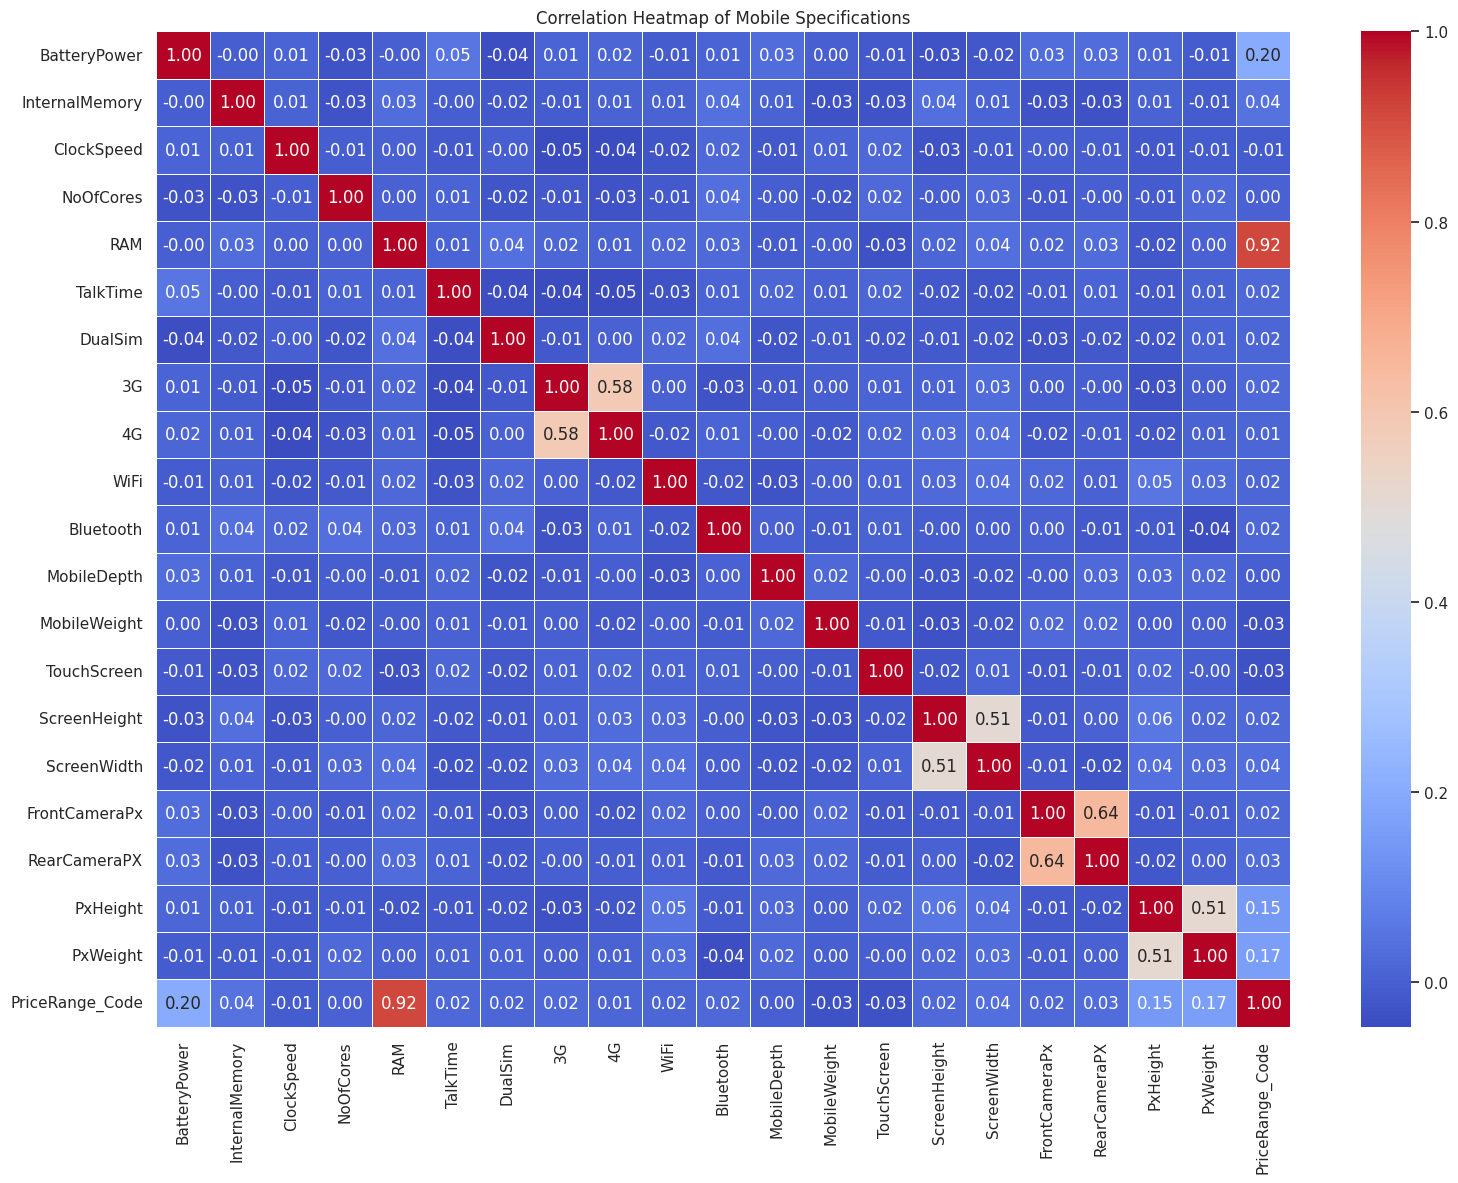

In [24]:
import os

os.makedirs("../images/heatmaps", exist_ok=True)

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Mobile Specifications")

plt.tight_layout()

plt.savefig(
    "../images/heatmaps/task6_correlation_heatmap.png",
    dpi=300
)

plt.show()

In [25]:
price_correlation = (
    correlation["PriceRange_Code"]
    .drop("PriceRange_Code")
    .sort_values(ascending=False)
)

price_correlation

,PriceRange_Code
RAM,0.917046
BatteryPower,0.200723
PxWeight,0.165818
PxHeight,0.148858
InternalMemory,0.044435
ScreenWidth,0.038711
RearCameraPX,0.033599
3G,0.023611
ScreenHeight,0.022986
FrontCameraPx,0.021998


In [26]:
positive_correlations = price_correlation[
    price_correlation > 0
].sort_values(ascending=False)

positive_correlations.head(10)

,PriceRange_Code
RAM,0.917046
BatteryPower,0.200723
PxWeight,0.165818
PxHeight,0.148858
InternalMemory,0.044435
ScreenWidth,0.038711
RearCameraPX,0.033599
3G,0.023611
ScreenHeight,0.022986
FrontCameraPx,0.021998


In [27]:
negative_correlations = price_correlation[
    price_correlation < 0
].sort_values()

negative_correlations.head(10)

,PriceRange_Code
TouchScreen,-0.030411
MobileWeight,-0.030302
ClockSpeed,-0.006606


In [28]:
absolute_correlation = (
    price_correlation.abs()
    .sort_values(ascending=False)
)

absolute_correlation.head(10)

,PriceRange_Code
RAM,0.917046
BatteryPower,0.200723
PxWeight,0.165818
PxHeight,0.148858
InternalMemory,0.044435
ScreenWidth,0.038711
RearCameraPX,0.033599
TouchScreen,0.030411
MobileWeight,0.030302
3G,0.023611


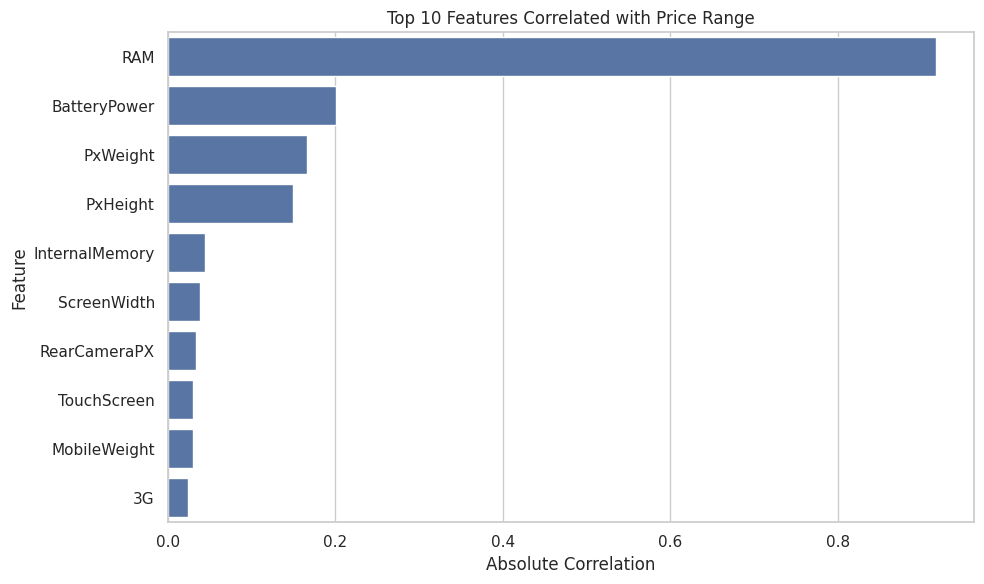

In [29]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create comparison folder if it doesn't exist
os.makedirs("../images/comparison", exist_ok=True)

# Select top 10 features based on absolute correlation
top_correlations = (
    price_correlation.abs()
    .sort_values(ascending=False)
    .head(10)
)

# Create bar plot
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_correlations.values,
    y=top_correlations.index
)

plt.title("Top 10 Features Correlated with Price Range")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.tight_layout()

# Save the graph
plt.savefig(
    "../images/comparison/top_price_correlations.png",
    dpi=300
)

plt.show()

In [30]:
strongest_feature = price_correlation.abs().idxmax()
strongest_value = price_correlation[strongest_feature]

print("Strongest correlated feature:", strongest_feature)
print("Correlation:", round(strongest_value, 4))

Strongest correlated feature: RAM
Correlation: 0.917


In [31]:
correlation_summary = pd.DataFrame({
    "Feature": price_correlation.index,
    "Correlation": price_correlation.values,
    "Absolute_Correlation": price_correlation.abs().values
})

correlation_summary = correlation_summary.sort_values(
    by="Absolute_Correlation",
    ascending=False
)

correlation_summary.head(15)

,Feature,Correlation,Absolute_Correlation
0,RAM,0.917046,0.917046
1,BatteryPower,0.200723,0.200723
2,PxWeight,0.165818,0.165818
3,PxHeight,0.148858,0.148858
4,InternalMemory,0.044435,0.044435
5,ScreenWidth,0.038711,0.038711
6,RearCameraPX,0.033599,0.033599
19,TouchScreen,-0.030411,0.030411
18,MobileWeight,-0.030302,0.030302
7,3G,0.023611,0.023611


In [32]:
os.makedirs("../data/processed", exist_ok=True)

correlation_summary.to_csv(
    "../data/processed/price_range_correlations.csv",
    index=False
)

print("Correlation analysis saved successfully!")

Correlation analysis saved successfully!


In [33]:
spearman_correlation = df.select_dtypes(
    include="number"
).corr(method="spearman")

spearman_price = (
    spearman_correlation["PriceRange_Code"]
    .drop("PriceRange_Code")
    .sort_values(ascending=False)
)

spearman_price.head(10)

,PriceRange_Code
RAM,0.917080
BatteryPower,0.199991
PxWeight,0.165134
PxHeight,0.131884
InternalMemory,0.044278
RearCameraPX,0.032824
ScreenWidth,0.024776
FrontCameraPx,0.024167
ScreenHeight,0.023727
3G,0.023611


## Key Insights

- The correlation matrix was generated to understand relationships among the numerical mobile specifications.
- PriceRange was encoded according to its natural order: Low, Medium, High, and VeryHigh.
- The features were ranked according to their correlation with PriceRange.
- The strongest positively correlated features indicate specifications that tend to increase as the price category increases.
- Features with weak correlations have a relatively weaker linear relationship with the price category.
- The correlation analysis helps identify potentially useful features for the classification models in the next level.

## Conclusion

Correlation analysis was successfully performed to identify the relationship between mobile specifications and price range. The strongest correlated features were identified and ranked. These results provide useful guidance for feature selection and classification model development.